# PASO 1: CARGA Y PREPARACIÓN PARA LA IA

En este paso cargamos nuestro dataset limpio y aplicamos Label Encoding mediante la librería Scikit-Learn para traducir las últimas variables de texto (como el nombre del municipio o el tipo de vivienda) a secuencias numéricas, ya que los algoritmos predictivos son puramente matemáticos y no saben interpretar palabras. Además, se elimina la columna del precio por metro cuadrado (price_m2) para evitar que el modelo calcule el precio final con una simple multiplicación en lugar de esforzarse por aprender los verdaderos patrones del mercado. Con esta transformación, logramos una matriz estructuralmente perfecta y numérica, lista para realizar el entrenamiento del modelo.

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Cargamos el dataset limpio
df = pd.read_csv('../data/processed/viviendas_sevilla_limpio.csv')

# 2. Borramos columnas "trampa" o redundantes antes de entrenar
columnas_a_borrar = ['price_m2', 'municipio_norm']
for col in columnas_a_borrar:
    if col in df.columns:
        df = df.drop(columns=[col])

# 3. Traducción de palabras a números 
diccionario_encoders = {}
columnas_texto = ['loc_city', 'loc_district', 'house_type']

for col in columnas_texto:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    diccionario_encoders[col] = le
    print(f"Columna '{col}' traducida a números.")

# 4. Comprobamos que todo el dataset es numérico
print("RESUMEN DEL DATASET PARA LA IA:")
print(df.info())
display(df.head())

Columna 'loc_city' traducida a números.
Columna 'loc_district' traducida a números.
Columna 'house_type' traducida a números.
RESUMEN DEL DATASET PARA LA IA:
<class 'pandas.DataFrame'>
RangeIndex: 4247 entries, 0 to 4246
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   price                        4247 non-null   int64  
 1   m2_real                      4247 non-null   int64  
 2   room_num                     4247 non-null   int64  
 3   bath_num                     4247 non-null   int64  
 4   loc_city                     4247 non-null   int64  
 5   loc_district                 4247 non-null   int64  
 6   house_type                   4247 non-null   int64  
 7   balcony                      4247 non-null   int64  
 8   garage                       4247 non-null   int64  
 9   swimming_pool                4247 non-null   int64  
 10  terrace                      4247 non-null   

,price,m2_real,room_num,bath_num,loc_city,loc_district,house_type,balcony,garage,swimming_pool,terrace,storage_room,lift,garden,is_needs_renovating,is_new_development,distancia_centro_sevilla_km,renta_bruta_media
0,1355000,519,5,6,25,785,1,1,1,1,1,1,0,1,0,0,8.61,13458.0
1,1300000,670,5,4,25,781,1,0,0,1,1,0,0,1,0,0,8.61,13458.0
2,1250000,709,5,5,25,785,6,0,1,1,0,0,0,1,0,0,8.61,13458.0
3,1000000,500,4,1,3,521,1,1,1,0,0,0,0,0,1,0,45.00,9670.0
4,780300,782,1,1,10,769,6,0,1,0,0,0,0,0,1,0,13.07,11486.0


# PASO 2: SEPARACIÓN DE DATOS

En este paso aplicamos la separación de la información para aislar el entorno de pruebas. Primero, dividimos nuestra tabla en dos grandes ejes: la matriz 'X', que contiene todas las características de las viviendas (los datos de estudio), y el vector 'y', que guarda exclusivamente el precio (las soluciones). Luego, partimos este conjunto empleando una proporción estándar del 80/20. Le entregamos el 80% de las casas al modelo para que entrene, aprenda y extraiga los patrones matemáticos del mercado inmobiliario, pero apartamos el 20% restante para realizar una evaluación independiente. Guardar esta muestra intacta nos sirve para evaluar el modelo con total objetividad. Al enfrentarlo a inmuebles que nunca ha procesado, comprobamos si el algoritmo ha desarrollado una capacidad real de generalización y entiende el mercado, descartando el riesgo de que sufra sobreajuste y simplemente se haya dedicado a memorizar nuestra tabla de origen.

In [3]:
# 1. Definimos la 'X' (lo que usamos para predecir) y la 'y' (lo que queremos predecir)
X = df.drop(columns=['price'])
y = df['price']

# 2. Primera división: extraemos el 80% para Entrenamiento y dejamos un 20% temporal
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Segunda división: partimos el temporal por la mitad (10% Validación y 10% Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Datos totales: {len(df)}")
print(f"Datos para que la IA estudie (Entrenamiento): {len(X_train)}")
print(f"Datos para ajustar hiperparámetros (Validación): {len(X_val)}")
print(f"Datos para examinar a la IA (Prueba): {len(X_test)}")

Datos totales: 4247
Datos para que la IA estudie (Entrenamiento): 3397
Datos para ajustar hiperparámetros (Validación): 425
Datos para examinar a la IA (Prueba): 425


# PASO 3: ELECCIÓN DEL MODELO Y ENTRENAMIENTO

En este paso, reemplazamos el procesamiento secuencial tradicional por computación distribuida con Dask. En lugar de sobrecargar un solo núcleo, configuramos un clúster local que distribuye el costoso cómputo del Random Forest Regressor entre múltiples hilos de ejecución simultáneos mediante la integración con joblib. Esta estrategia de paralelismo reduce significativamente los tiempos de entrenamiento y prepara el código para una escalabilidad futura: la misma estructura puede migrar sin cambios a servidores en la nube para procesar volúmenes masivos de datos. El proceso concluye con la liberación controlada de la memoria RAM del sistema.

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

print("Iniciando bucle de hiperparámetros (GridSearch) para Random Forest...")

# 1. 72 combinaciones posibles
param_grid = {
    'n_estimators': [100, 300, 500],        # Bosques mucho más frondosos
    'max_depth': [None, 15, 25],            # Límites de profundidad estratégica
    'min_samples_split': [2, 5],            # Exigencia para crear nuevas ramas
    'min_samples_leaf': [1, 2],             # Exigencia para cerrar una rama (evita overfitting)
    'max_features': ['sqrt', 1.0]           # Cuántas variables mira a la vez
}

# 2. Configuramos el bucle (cv=3 pliegues)
rf_base = RandomForestRegressor(random_state=42)
# n_jobs=-1 usa todos los núcleos del procesador para ir más rápido
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           cv=3, scoring='r2', n_jobs=-1, verbose=1)

# 3. Entrenamos
grid_search.fit(X_train, y_train)

# 4. Nos quedamos con el mejor modelo ganador
modelo_viviendas = grid_search.best_estimator_

print("¡Bucle de Random Forest terminado!")
print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")

Iniciando bucle de hiperparámetros (GridSearch) para Random Forest...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
¡Bucle de Random Forest terminado!
Mejores hiperparámetros encontrados: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}


# PASO 4: EVALUACIÓN DEL MODELO

Para evaluar el rendimiento de nuestros modelos mediante la librería Scikit-Learn, hemos descartado métricas que penalizan excesivamente los valores atípicos (como el MSE o el RMSE) y hemos optado por dos métricas estadísticas fundamentales:

*   **Error Absoluto Medio (MAE):** En el mercado inmobiliario existen propiedades de lujo que pueden actuar como *outliers* y disparar los errores al cuadrado. El MAE es robusto ante estos valores atípicos y, lo más importante, nos devuelve el error en la misma unidad de medida que nuestro objetivo (Euros). Esto nos permite traducir el rendimiento técnico de la IA a una métrica de negocio totalmente comprensible para el cliente final (ej. "nuestro tasador automático tiene un margen de error promedio de X euros").

*   **Coeficiente de Determinación ($R^2$):** Utilizamos esta métrica como indicador global de la calidad del modelo, ya que nos indica qué porcentaje de la variabilidad del precio de las viviendas en Sevilla es capaz de ser explicada matemáticamente por las variables de nuestro *dataset* (metros cuadrados, renta del barrio, extras, etc.).

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. La IA hace el examen
predicciones = modelo_viviendas.predict(X_test)

# 2. Comparamos las respuestas de la IA con la realidad
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f"Error Medio (MAE): {mae:,.2f} €")
print(f"Puntuación de precisión (R2): {r2:.4f}")

# 3. Vamos a ver un ejemplo real de las primeras 5 casas del examen
print("COMPARATIVA: REAL VS PREDICCIÓN")
comparativa = pd.DataFrame({'Precio Real': y_test, 'Predicción IA': predicciones}).head()
display(comparativa)

Error Medio (MAE): 27,613.95 €
Puntuación de precisión (R2): 0.8587
COMPARATIVA: REAL VS PREDICCIÓN


,Precio Real,Predicción IA
2384,121000,152709.292792
2442,120000,122538.221904
4032,50000,67954.391606
3268,83900,98674.232201
1017,207000,193190.533949


En este bloque implementamos una arquitectura de Deep Learning utilizando PyTorch. Primero, aplicamos una estandarización a nuestros datos (StandardScaler), para que las redes neuronales no colapsen matemáticamente. A continuación, diseñamos una Red Neuronal Convolucional 1D (CNN), una arquitectura moderna que tradicionalmente se usa para procesar señales o imágenes, pero que aquí adaptamos para extraer patrones complejos de las características de las viviendas. Dividimos el proceso en dos fases: un pre-entrenamiento inicial para que la red aprenda la estructura base de los datos, seguido de un proceso de Fine-Tuning (ajuste fino) donde congelamos las capas iniciales y entrenamos solo la cabeza de la red para especializarla en la tasación final. Por último, enfrentamos los resultados de esta red neuronal contra nuestro modelo Random Forest anterior, permitiéndonos evaluar de forma empírica qué arquitectura entiende mejor el mercado inmobiliario sevillano.

In [12]:
# Verificamos si las variables necesarias existen
try:
    X_train
except NameError:
    print("Variables no encontradas. Asegúrate de ejecutar los pasos anteriores.")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import copy 

# 1. Escalamos los datos X (INCLUYENDO VALIDACIÓN)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)
X_test_scaled = scaler_x.transform(X_test)

# DEEP LEARNING (PYTORCH)

modelo_pytorch = None
mae_dl = None
r2_dl = None
backend_name = None

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    backend_name = 'PyTorch'
    
    print(f"Iniciando Deep Learning con {backend_name}...")
    
    # BLOQUEAMOS LA ALEATORIEDAD PARA QUE EL R2 NO VARIE
    torch.manual_seed(42)
    np.random.seed(42)
    
    # 2. Escalar la 'y' para que PyTorch no colapse 
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
    
    # 3. Convertir a Tensores
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
    X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).unsqueeze(1)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
    
    y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)
    
    n_features = X_train_scaled.shape[1]
    
    # Arquitectura Base (Feature Extractor)
    class BaseCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv1d(1, 32, kernel_size=2)
            self.relu = nn.ReLU()
            self.flatten = nn.Flatten()
            self.fc1 = nn.Linear(32 * (n_features - 1), 32)
            self.dropout = nn.Dropout(0.2)
            
        def forward(self, x):
            return self.dropout(self.relu(self.fc1(self.flatten(self.relu(self.conv1(x))))))
            
    # --- FASE 1: PRE-ENTRENAMIENTO BASE ---
    modelo_base = BaseCNN()
    cabeza_pre = nn.Linear(32, 1)
    
    opt_pre = optim.Adam(list(modelo_base.parameters()) + list(cabeza_pre.parameters()), lr=0.01)
    criterio = nn.MSELoss()
    
    print("Iniciando Pre-entrenamiento de la Base...")
    for epoch in range(50):
        modelo_base.train()
        opt_pre.zero_grad()
        perdida_train = criterio(cabeza_pre(modelo_base(X_train_t)), y_train_t)
        perdida_train.backward()
        opt_pre.step()
        
    for param in modelo_base.parameters():
        param.requires_grad = False 

    # --- FASE 2: BUCLE DE HIPERPARÁMETROS MEJORADO ---
    print("\nIniciando búsqueda de hiperparámetros para el Fine-Tuning...")
    
    # Hemos ampliado la red para que busque opciones más agresivas y conservadoras
    opciones_hiperparametros = [
        {'lr': 0.01, 'epochs': 100},
        {'lr': 0.008, 'epochs': 120},
        {'lr': 0.005, 'epochs': 150}, # Tu configuración original
        {'lr': 0.001, 'epochs': 250}  # Aprendizaje lento pero profundo
    ]
    
    mejor_loss = float('inf')
    mejor_config = None
    mejores_pesos_head = None
    
    cabeza_ft_molde = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1))
    pesos_iniciales_head = copy.deepcopy(cabeza_ft_molde.state_dict())

    for config in opciones_hiperparametros:
        lr = config['lr']
        epochs = config['epochs']
        print(f"Probando -> Learning Rate: {lr} | Épocas: {epochs}")
        
        cabeza_ft = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1))
        cabeza_ft.load_state_dict(pesos_iniciales_head)
        
        opt_ft = optim.Adam(cabeza_ft.parameters(), lr=lr)
        
        for epoch in range(epochs):
            cabeza_ft.train()
            opt_ft.zero_grad()
            perdida_train = criterio(cabeza_ft(modelo_base(X_train_t)), y_train_t)
            perdida_train.backward()
            opt_ft.step()
            
        cabeza_ft.eval()
        with torch.no_grad():
            perdida_val = criterio(cabeza_ft(modelo_base(X_val_t)), y_val_t)
            
        print(f"Loss Final Validación: {perdida_val.item():.4f}")
        
        if perdida_val.item() < mejor_loss:
            mejor_loss = perdida_val.item()
            mejor_config = config
            mejores_pesos_head = copy.deepcopy(cabeza_ft.state_dict())
            
    # --- APLICAMOS LA MEJOR CONFIGURACIÓN ENCONTRADA ---
    cabeza_ft.load_state_dict(mejores_pesos_head)
    print("-" * 50)
    print(f"Mejor configuración: {mejor_config} con Loss: {mejor_loss:.4f}")
            
    # EVALUACIÓN FINAL USANDO TEST (Con la mejor IA)
    modelo_base.eval()
    cabeza_ft.eval()
    with torch.no_grad():
        pred_scaled = cabeza_ft(modelo_base(X_test_t)).numpy()
        predicciones_dl = scaler_y.inverse_transform(pred_scaled).flatten()
        
    mae_dl = mean_absolute_error(y_test, predicciones_dl)
    r2_dl = r2_score(y_test, predicciones_dl)

    print(f"\nRED NEURONAL ({backend_name} CNN 1D Fine-Tuned) - MAE EN TEST: {mae_dl:,.2f} € | R2 EN TEST: {r2_dl:.4f}")

except ImportError:
    print("No se encontró PyTorch. Instala PyTorch.")

# COMPARACIÓN FINAL
try:
    print(f"\nCOMPARACIÓN DE ARQUITECTURAS EN TEST:")
    print(f"Random Forest -> MAE: {mae:,.2f} € | R2: {r2:.4f}")
    if mae_dl is not None:
        print(f"NN Moderna ({backend_name}) -> MAE: {mae_dl:,.2f} € | R2: {r2_dl:.4f}")

except NameError:
    print("Nota: Asegúrate de ejecutar antes la celda de Random Forest para ver la comparativa.")

Iniciando Deep Learning con PyTorch...
Iniciando Pre-entrenamiento de la Base...

Iniciando búsqueda de hiperparámetros para el Fine-Tuning...
Probando -> Learning Rate: 0.01 | Épocas: 100
Loss Final Validación: 0.3011
Probando -> Learning Rate: 0.008 | Épocas: 120
Loss Final Validación: 0.2696
Probando -> Learning Rate: 0.005 | Épocas: 150
Loss Final Validación: 0.2660
Probando -> Learning Rate: 0.001 | Épocas: 250
Loss Final Validación: 0.2966
--------------------------------------------------
Mejor configuración: {'lr': 0.005, 'epochs': 150} con Loss: 0.2660

RED NEURONAL (PyTorch CNN 1D Fine-Tuned) - MAE EN TEST: 34,334.62 € | R2 EN TEST: 0.7858

COMPARACIÓN DE ARQUITECTURAS EN TEST:
Random Forest -> MAE: 27,613.95 € | R2: 0.8587
NN Moderna (PyTorch) -> MAE: 34,334.62 € | R2: 0.7858


El modelo Random Forest supera a la red neuronal (Deep Learning), logrando menos margen de error y mayor precisión, por lo que para nuestro listado de viviendas, el Random Forest es, sin duda, la herramienta ganadora.

# PASO 5: ¿QUÉ ES LO MÁS IMPORTANTE PARA EL PRECIO?

Uno de los puntos críticos de cualquier proyecto de Inteligencia Artificial moderna es entender el porqué de sus decisiones, para generar confianza, aportar transparencia y ofrecer recomendaciones estratégicas reales al sector inmobiliario.

Para ello, hemos analizado la lógica interna y el proceso de inferencia de nuestros dos modelos:

*   **Random Forest:** Utiliza su métrica nativa de importancia de características, que evalúa qué variables reducen más la impureza matemática a la hora de construir los árboles de decisión.
*   **Deep Learning (PyTorch CNN 1D):** Debido a la alta complejidad computacional y a la falta de interpretabilidad directa que suelen presentar las redes neuronales, hemos implementado un algoritmo de Importancia por Permutación. Este método selecciona cada variable del conjunto de prueba, altera sus valores de forma aleatoria y cuantifica cuánto empeora el error absoluto (MAE) de la predicción. Si el margen de error aumenta significativamente, se concluye que dicha característica posee un alto poder explicativo para la arquitectura.

Mediante los siguientes gráficos de barras horizontales, mostramos de forma transparente y estructurada cuáles son los factores que realmente determinan el precio de la vivienda en Sevilla.

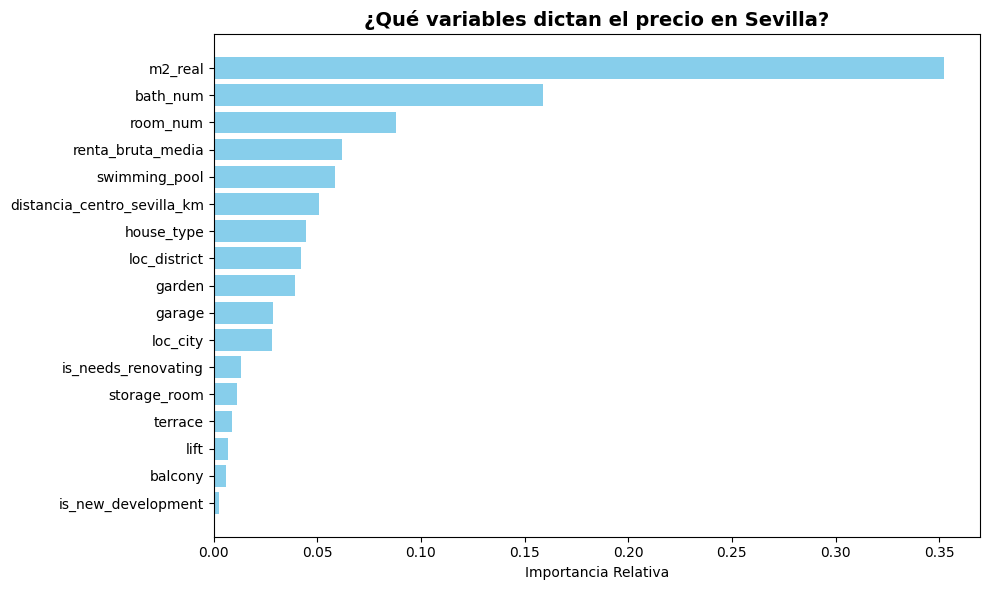

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Sacamos la importancia de cada variable
importancias = modelo_viviendas.feature_importances_
columnas = X.columns
indices = np.argsort(importancias)

# 2. Creamos el gráfico
plt.figure(figsize=(10, 6))
plt.title('¿Qué variables dictan el precio en Sevilla?', fontsize=14, fontweight='bold')
plt.barh(range(len(indices)), importancias[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [columnas[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.show()

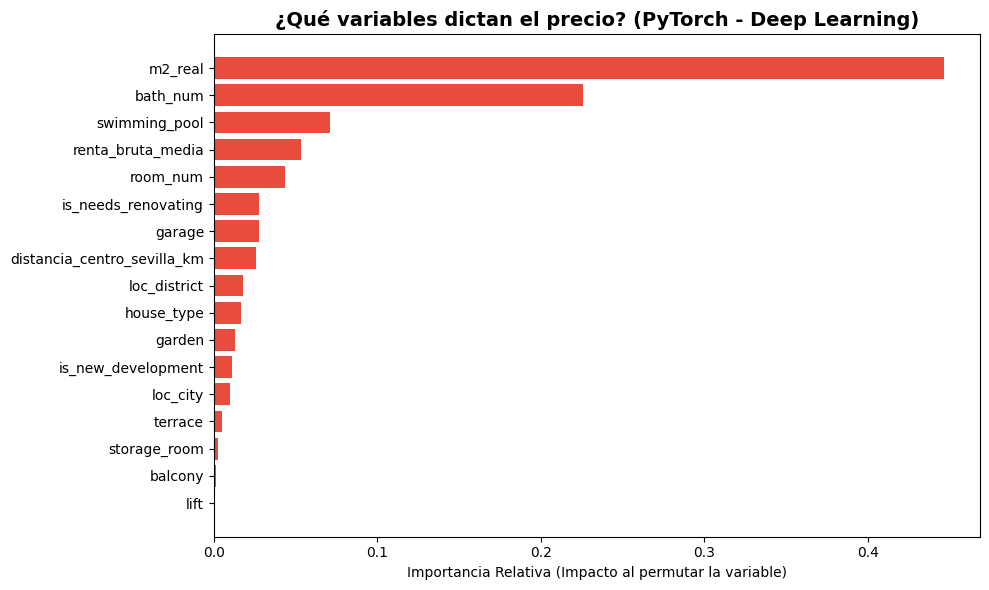

In [10]:
# 3. Importancia en Deep Learning 
importancias_pt = []
baseline_mae = mae_dl 

# Copiamos los datos escalados de prueba
X_test_np = X_test_scaled.copy()

modelo_base.eval()
cabeza_ft.eval()

# Bucle de permutación: desordenamos una a una las variables
for i in range(X_test_np.shape[1]):
    X_shuffled = X_test_np.copy()
    np.random.shuffle(X_shuffled[:, i])
    
    X_shuffled_t = torch.tensor(X_shuffled, dtype=torch.float32).unsqueeze(1)
    with torch.no_grad():
        pred_scaled = cabeza_ft(modelo_base(X_shuffled_t)).numpy()
        predicciones_shuffled = scaler_y.inverse_transform(pred_scaled).flatten()
        
    shuffled_mae = mean_absolute_error(y_test, predicciones_shuffled)
    importancias_pt.append(shuffled_mae - baseline_mae)
    
# Normalizamos para comparar en porcentaje (entre 0 y 1)
importancias_pt = np.array(importancias_pt)
importancias_pt = np.maximum(importancias_pt, 0)
if importancias_pt.sum() > 0:
    importancias_pt = importancias_pt / importancias_pt.sum()
    
indices_pt = np.argsort(importancias_pt)

# Gráfico PyTorch
plt.figure(figsize=(10, 6))
plt.title('¿Qué variables dictan el precio? (PyTorch - Deep Learning)', fontsize=14, fontweight='bold')
plt.barh(range(len(indices_pt)), importancias_pt[indices_pt], color='#E74C3C', align='center')
plt.yticks(range(len(indices_pt)), [columnas[i] for i in indices_pt])
plt.xlabel('Importancia Relativa (Impacto al permutar la variable)')
plt.tight_layout()
plt.show()

# PASO 6: GUARDADO DEL DATASET PROCESADO

En este paso final, utilizando las librerías `joblib` y `torch`, exportamos  nuestros dos algoritmos ya entrenados: el modelo clásico (Random Forest) y la arquitectura de Deep Learning (PyTorch CNN 1D). 

No solo guardamos los modelos matemáticos, sino que también empaquetamos el diccionario completo de *Label Encoders* (para traducir las palabras del usuario a números) y los *Scalers* (para normalizar los datos de entrada en la misma escala exacta que vio la red neuronal durante su aprendizaje). Al salvar todos estos componentes de forma estructurada, dejamos el proyecto completamente preparado para producción. De esta manera, nuestra aplicación web podrá recibir las características de un nuevo inmueble en texto plano, aplicarles automáticamente las mismas transformaciones matemáticas y ofrecer una tasación interactiva y precisa sin necesidad de volver a ejecutar el código de entrenamiento.

In [11]:
import joblib
import os
import torch

# 1. Creamos la carpeta 'models' si no existe
if not os.path.exists('../models'):
    os.makedirs('../models')

# 2. Guardamos el modelo Random Forest y encoders
joblib.dump(modelo_viviendas, '../models/modelo_casas_sevilla.pkl')
joblib.dump(diccionario_encoders, '../models/diccionario_encoders.pkl')

# 3. Guardamos los Scalers para que la IA pueda escalar los datos nuevos de forma idéntica a como se entrenó
joblib.dump(scaler_x, '../models/scaler_x.pkl')
joblib.dump(scaler_y, '../models/scaler_y.pkl')

# 4. Guardamos la Red Neuronal 
torch.save({
    'base': modelo_base,
    'head': cabeza_ft
}, '../models/modelo_pytorch.pth')

print("Modelos (RF y PyTorch), Encoders y Scalers guardados correctamente en la carpeta /models")

Modelos (RF y PyTorch), Encoders y Scalers guardados correctamente en la carpeta /models
